In [1]:
import hoda
import tensorly as tl
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = EPFLP300()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)

session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]
#epochs._data = Scaler(scalings='mean').fit_transform(epochs._data)

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
/usr/local/lib/python3.10/dist-packages/moabb/datasets/download.py:55: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_EPFLP3

To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:85: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)
/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:85: RuntimeWarning: Limited 3 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)
/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:85: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)
/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:85: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)
/usr/local/lib/python3.10/dist-packages/moabb/datasets/preprocessing.py:85: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)
/usr/local/lib/python3.10

Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
3317 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
epochs

Number of events,854
Events,NonTarget: 712Target: 142
Time range,0.000 – 0.781 s
Baseline,off


Not setting metadata
854 matching events found
No baseline correction applied
0 projection items activated
combining channels using "gfp"


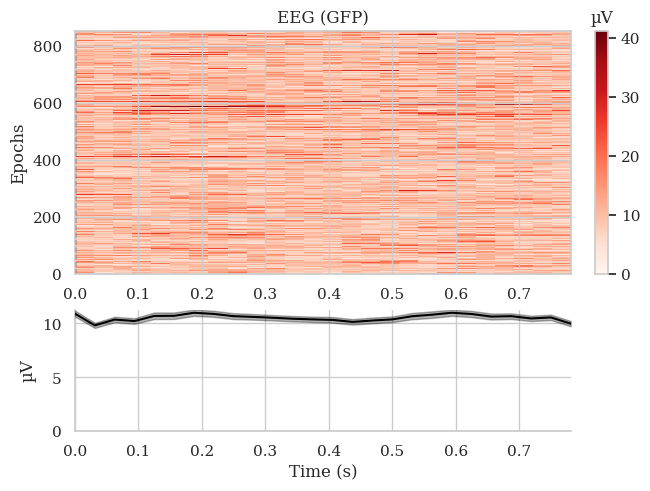

[<Figure size 640x480 with 3 Axes>]

In [4]:
epochs.plot_image()

In [5]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
849,1,0,5
850,1,0,5
851,1,0,5
852,1,0,5


In [6]:
X = epochs.get_data()
y = labels

X.shape

/tmp/ipykernel_5099/2444922706.py:1: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(854, 32, 26)

In [7]:
from hoda.hoda import HODA, f_multiway,trunc_eigh
from hoda.cov import ledoit_wolf_shrinkage, oas, mode_scatter
import warnings

from hoda.hoda import f_oneway, mode_scatter
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd
from sklearn.preprocessing import StandardScaler


hoda = HODA(
    rank=None,
    max_iter=512,
    tol=1e-12,
    init ='mlsvd',
    shrinkage='lw',
    toeplitz=(1,),
    obj='rt',
    solver='lobpcg',
    taper=False,
    extra_train_info=False,
    verbose=True,
)

hoda

HODA(init='mlsvd', max_iter=512, solver='lobpcg', toeplitz=(1,), tol=1e-12,
     verbose=True)

In [8]:
import matplotlib.pyplot as plt
from hoda.hoda import log_likelihood, bic, aic, aicc
import math


bics = []
aics=[]
aiccs=[]
lls = []
mses=[]
n_params = []

n_samples = X.shape[0]
for r in range(1,min(X.shape[1:])+1):
    hoda.set_params(rank=r)
    hoda.fit(X,y)
    Xt = hoda.transform(X)
    mses.append(float(tl.metrics.regression.MSE(tl.tensor(X),hoda.inv_transform(Xt))))
    log_like = log_likelihood(Xt,y)
    print(log_like)
    lls.append(float(log_like))
    k = math.prod(hoda.ml_rank_)
    n_params.append(k)
    bics.append(float(bic(n_samples,k,log_like)))
    aics.append(float(aic(n_samples,k,log_like)))
    aiccs.append(float(aicc(n_samples,k,log_like)))



Fitting discriminative Tucker model of rank (1, 1)...


  0%|          | 0/512 [00:00<?, ?it/s]

-278.6402569391453
Fitting discriminative Tucker model of rank (2, 2)...


  0%|          | 0/512 [00:00<?, ?it/s]

-232.92253379084804
Fitting discriminative Tucker model of rank (3, 3)...


...

-67.69414416707914
Fitting discriminative Tucker model of rank (25, 25)...


  0%|          | 0/512 [00:00<?, ?it/s]

-64.87617554394917
Fitting discriminative Tucker model of rank (26, 26)...


  0%|          | 0/512 [00:00<?, ?it/s]

-59.85236120878807


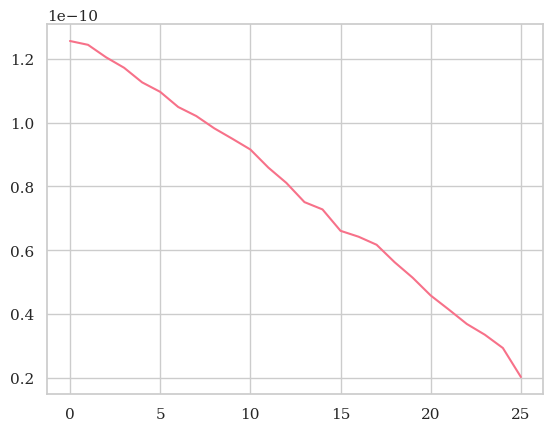

In [9]:
plt.plot(mses)

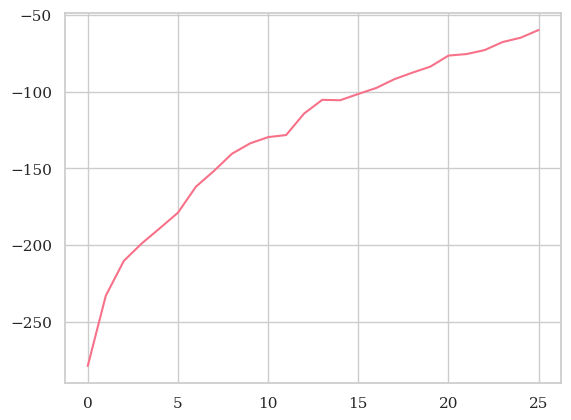

In [10]:
plt.plot(lls)

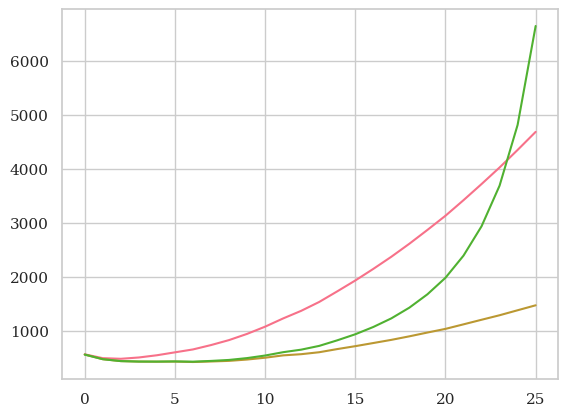

In [11]:
plt.plot(bics)
plt.plot(aics)
plt.plot(aiccs)

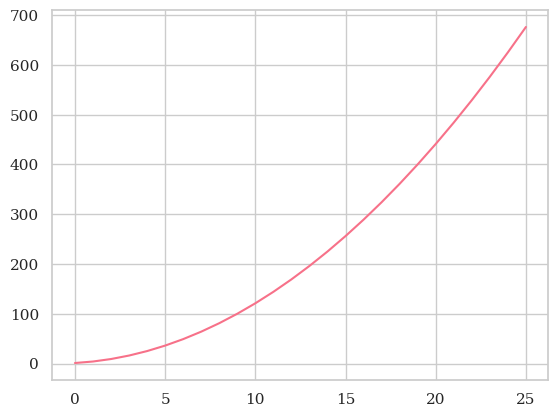

In [12]:
plt.plot(n_params)